In [ ]:
# IDEC Implementation
from __future__ import print_function, division

# required packages
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision", "scikit-learn", "scipy"])

import argparse
import numpy as np
import pickle
import os
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_rand_score as ari_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import Linear
from torchvision import datasets, transforms

print("✓ All imports loaded successfully!")

✓ All imports loaded successfully!


In [ ]:

# Utilities


def cluster_acc(y_true, y_pred):
    #Calculate clustering accuracy
    from scipy.optimize import linear_sum_assignment
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)
    assert y_pred.size == y_true.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return sum(w[row_ind, col_ind]) * 1.0 / y_pred.size

def load_mnist_dataset():
    #Load full MNIST dataset
    print("Loading MNIST")
    transform = transforms.Compose([transforms.ToTensor()])
    
    # Download and load MNIST
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    # Combine train and test for full dataset (70,000 samples)
    train_data = train_dataset.data.numpy().astype(np.float32) / 255.0
    train_labels = train_dataset.targets.numpy()
    test_data = test_dataset.data.numpy().astype(np.float32) / 255.0
    test_labels = test_dataset.targets.numpy()
    
    X = np.vstack([train_data, test_data])
    y = np.concatenate([train_labels, test_labels])
    
    # Flatten images to 784 dimensions
    X = X.reshape(X.shape[0], -1)
    
    print(f"MNIST loaded: {X.shape[0]:,} samples, {X.shape[1]} features")
    return X, y

def save_clustering_results(results_dir, model_state, y_pred, y_true, metrics):
    #Saving Results
    os.makedirs(results_dir, exist_ok=True)
    
    results = {
        'y_pred': y_pred,
        'y_true': y_true,
        'accuracy': metrics['acc'],
        'nmi': metrics['nmi'],
        'ari': metrics['ari'],
        'n_samples': len(y_true),
        'n_clusters': len(np.unique(y_pred))
    }
    
    with open(os.path.join(results_dir, 'clustering_results.pkl'), 'wb') as f:
        pickle.dump(results, f)
    
    torch.save(model_state, os.path.join(results_dir, 'idec_model.pth'))
    np.save(os.path.join(results_dir, 'y_pred.npy'), y_pred)
    np.save(os.path.join(results_dir, 'y_true.npy'), y_true)
    
    print(f"✓ Results saved to {results_dir}")
    return results_dir

def print_clustering_results(y_true, y_pred, metrics):
    """Print detailed clustering results"""
    print('\n' + '=' * 70)
    print('FINAL CLUSTERING RESULTS')
    print('=' * 70)
    print(f'Clustering Accuracy (ACC): {metrics["acc"]:.4f} ({metrics["acc"]*100:.2f}%)')
    print(f'Normalized Mutual Info (NMI): {metrics["nmi"]:.4f}')
    print(f'Adjusted Rand Index (ARI): {metrics["ari"]:.4f}')
    print('=' * 70)
    
    # Cluster-to-class mapping
    print('\nDETAILED CLUSTER-TO-CLASS MAPPING')
    print('=' * 70)
    n_clusters = len(np.unique(y_pred))
    for cluster_id in range(n_clusters):
        mask = (y_pred == cluster_id)
        true_labels = y_true[mask]
        if len(true_labels) > 0:
            unique, counts = np.unique(true_labels, return_counts=True)
            most_common = unique[np.argmax(counts)]
            purity = counts.max() / len(true_labels) * 100
            print(f'Cluster {cluster_id}: Dominant={most_common}, Purity={purity:.2f}%, Samples={len(true_labels):,}')
    
    # Confusion matrix
    print('\nCONFUSION MATRIX (True Labels vs Predicted Clusters):')
    print('   ', end='')
    for c in range(n_clusters):
        print(f'C{c:2d} ', end='')
    print()
    for true_digit in range(10):
        print(f'{true_digit}: ', end='')
        for cluster_id in range(n_clusters):
            count = np.sum((y_true == true_digit) & (y_pred == cluster_id))
            print(f'{count:4d}' if count > 0 else '   .', end=' ')
        print()
    print('=' * 70)

print("✓ Utility functions defined")

✓ Utility functions defined


In [ ]:

# Model Architecture Module
class AE(nn.Module):
    #Autoencoder

    def __init__(self, n_enc_1, n_enc_2, n_enc_3, n_dec_1, n_dec_2, n_dec_3,
                 n_input, n_z):
        super(AE, self).__init__()

        # encoder
        self.enc_1 = Linear(n_input, n_enc_1)
        self.enc_2 = Linear(n_enc_1, n_enc_2)
        self.enc_3 = Linear(n_enc_2, n_enc_3)
        self.z_layer = Linear(n_enc_3, n_z)

        # decoder
        self.dec_1 = Linear(n_z, n_dec_1)
        self.dec_2 = Linear(n_dec_1, n_dec_2)
        self.dec_3 = Linear(n_dec_2, n_dec_3)
        self.x_bar_layer = Linear(n_dec_3, n_input)

    def forward(self, x):
        enc_h1 = F.relu(self.enc_1(x))
        enc_h2 = F.relu(self.enc_2(enc_h1))
        enc_h3 = F.relu(self.enc_3(enc_h2))
        z = self.z_layer(enc_h3)

        dec_h1 = F.relu(self.dec_1(z))
        dec_h2 = F.relu(self.dec_2(dec_h1))
        dec_h3 = F.relu(self.dec_3(dec_h2))
        x_bar = self.x_bar_layer(dec_h3)
        return x_bar, z


class IDEC(nn.Module):
    #Improved Deep Embedded Clustering

    def __init__(self, n_enc_1, n_enc_2, n_enc_3, n_dec_1, n_dec_2, n_dec_3,
                 n_input, n_z, n_clusters, alpha=1, pretrain_path='data/ae_mnist.pth'):
        super(IDEC, self).__init__()
        self.alpha = alpha
        self.pretrain_path = pretrain_path

        self.ae = AE(n_enc_1=n_enc_1, n_enc_2=n_enc_2, n_enc_3=n_enc_3,
                     n_dec_1=n_dec_1, n_dec_2=n_dec_2, n_dec_3=n_dec_3,
                     n_input=n_input, n_z=n_z)
        self.cluster_layer = Parameter(torch.Tensor(n_clusters, n_z))
        torch.nn.init.xavier_normal_(self.cluster_layer.data)

    def pretrain(self, X, device, epochs=100):
        #Pretrain autoencoder
        print('\n' + '=' * 70)
        print(f'Pretraining Autoencoder ({epochs} epochs)...')
        print('=' * 70)
        
        dataset = TensorDataset(torch.FloatTensor(X))
        loader = DataLoader(dataset, batch_size=256, shuffle=True)
        optimizer = Adam(self.ae.parameters(), lr=0.001)
        
        for epoch in range(epochs):
            total_loss = 0.0
            for batch_idx, (x,) in enumerate(loader):
                x = x.to(device)
                optimizer.zero_grad()
                x_bar, _ = self.ae(x)
                loss = F.mse_loss(x_bar, x)
                total_loss += loss.item()
                loss.backward()
                optimizer.step()
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}: loss={total_loss / (batch_idx + 1):.6f}")
        
        torch.save(self.ae.state_dict(), self.pretrain_path)
        print(f"✓ Model saved to {self.pretrain_path}")

    def load_pretrain(self):
        #Load pretrained weights
        if os.path.exists(self.pretrain_path):
            self.ae.load_state_dict(torch.load(self.pretrain_path))
            print(f'✓ Loaded pretrained AE from {self.pretrain_path}')
        else:
            print(f'Warning: Pretrain path {self.pretrain_path} not found')

    def forward(self, x):
        x_bar, z = self.ae(x)
        q = 1.0 / (1.0 + torch.sum(
            torch.pow(z.unsqueeze(1) - self.cluster_layer, 2), 2) / self.alpha)
        q = q.pow((self.alpha + 1.0) / 2.0)
        q = (q.t() / torch.sum(q, 1)).t()
        return x_bar, q


def target_distribution(q):
    """Calculate target distribution"""
    weight = q ** 2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()

print("✓ Model architecture classes defined")

✓ Model architecture classes defined


In [ ]:
# ============================================================================
# TRAINING MODULE
# ============================================================================

def train_idec(X, y, device, args):
    
    # Initialize model
    model = IDEC(
        n_enc_1=500, n_enc_2=500, n_enc_3=1000,
        n_dec_1=1000, n_dec_2=500, n_dec_3=500,
        n_input=args.n_input, n_z=args.n_z,
        n_clusters=args.n_clusters, alpha=1.0,
        pretrain_path=args.pretrain_path).to(device)
    
    # Pretrain autoencoder
    model.pretrain(X, device, epochs=args.pretrain_epochs)
    model.load_pretrain()
    
    # Prepare data
    X_tensor = torch.FloatTensor(X).to(device)
    dataset = TensorDataset(X_tensor)
    loader = DataLoader(dataset, batch_size=args.batch_size, shuffle=False)
    
    # Initialize cluster centers
    print('\nInitializing cluster centers with KMeans...')
    with torch.no_grad():
        _, hidden = model.ae(X_tensor)
    kmeans = KMeans(n_clusters=args.n_clusters, n_init=20, random_state=42)
    y_pred = kmeans.fit_predict(hidden.data.cpu().numpy())
    model.cluster_layer.data = torch.tensor(kmeans.cluster_centers_).to(device)
    
    nmi_k = nmi_score(y, y_pred)
    print(f"Initial NMI score: {nmi_k:.4f}")
    
    # Training
    print('\n' + '=' * 70)
    print('Training IDEC Model...')
    print('=' * 70)
    
    optimizer = Adam(model.parameters(), lr=args.lr)
    y_pred_last = y_pred.copy()
    model.train()
    
    for epoch in range(args.epochs):
        if epoch % args.update_interval == 0:
            # Evaluate and update
            with torch.no_grad():
                _, tmp_q = model(X_tensor)
                tmp_q = tmp_q.data
            p = target_distribution(tmp_q)
            
            y_pred = tmp_q.cpu().numpy().argmax(1)
            delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
            y_pred_last = y_pred.copy()
            
            acc = cluster_acc(y, y_pred)
            nmi = nmi_score(y, y_pred)
            ari = ari_score(y, y_pred)
            
            print(f'Epoch {epoch:3d}: Acc={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, delta={delta_label:.6f}')
            
            if epoch > 0 and delta_label < args.tol:
                print(f'Converged (delta={delta_label:.6f} < tol={args.tol}). Stopping.')
                break
        else:
            # Just get predictions for KL loss
            with torch.no_grad():
                _, tmp_q = model(X_tensor)
                p = target_distribution(tmp_q.data)
        
        # Training step
        for batch_idx, (x,) in enumerate(loader):
            x = x.to(device)
            idx = batch_idx * args.batch_size
            
            x_bar, q = model(x)
            reconstr_loss = F.mse_loss(x_bar, x)
            kl_loss = F.kl_div(q.log(), p[idx:idx+x.size(0)])
            loss = args.gamma * kl_loss + reconstr_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    print('=' * 70)
    print('✓ IDEC Training Complete!')
    print('=' * 70)
    
    return model, y_pred, {'acc': acc, 'nmi': nmi, 'ari': ari}

print("✓ Training function defined")

✓ Training function defined


In [ ]:
# MAIN EXECUTION


# Setup arguments
parser = argparse.ArgumentParser(description='IDEC - MNIST Clustering')

# Data parameters
parser.add_argument('--dataset', type=str, default='mnist')
parser.add_argument('--n_clusters', default=10, type=int)
parser.add_argument('--n_input', default=784, type=int)
parser.add_argument('--n_z', default=10, type=int)

# Training parameters
parser.add_argument('--lr', type=float, default=0.001)
parser.add_argument('--batch_size', default=256, type=int)
parser.add_argument('--pretrain_epochs', default=100, type=int)
parser.add_argument('--epochs', default=100, type=int)
parser.add_argument('--update_interval', default=10, type=int)
parser.add_argument('--tol', default=0.001, type=float)
parser.add_argument('--gamma', default=0.1, type=float, help='coefficient of clustering loss')

# Paths
parser.add_argument('--pretrain_path', type=str, default='data/ae_mnist.pth')
parser.add_argument('--results_dir', type=str, default='results')

args = parser.parse_args([])  # Empty list for notebook execution

# Setup device
args.cuda = torch.cuda.is_available()
print(f"Use CUDA: {args.cuda}")
device = torch.device("cuda" if args.cuda else "cpu")

# Load data
X, y = load_mnist_dataset()

# Train IDEC
model, y_pred, metrics = train_idec(X, y, device, args)

# Print and save results
print_clustering_results(y, y_pred, metrics)
save_clustering_results(args.results_dir, model.state_dict(), y_pred, y, metrics)

print("\n✓ Training complete!")

Use CUDA: False
Loading MNIST
MNIST loaded: 70,000 samples, 784 features

Pretraining Autoencoder (100 epochs)...
Epoch 10/100: loss=0.015066


In [ ]:

# VIEW FINAL CLUSTERING RESULTS


import pickle
import numpy as np
import pandas as pd

# Load the results
with open('results/clustering_results.pkl', 'rb') as f:
    results = pickle.load(f)

print('=' * 70)
print('FINAL CLUSTERING RESULTS SUMMARY')
print('=' * 70)
print(f"Total Samples: {results['n_samples']:,}")
print(f"Number of Clusters: {results['n_clusters']}")
print(f"Accuracy: {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"NMI Score: {results['nmi']:.4f}")
print(f"ARI Score: {results['ari']:.4f}")
print('=' * 70)

# Load predictions and true labels
y_pred = results['y_pred']
y_true = results['y_true']

# Show first 50 sample assignments
print('\n' + '=' * 70)
print('FIRST 50 SAMPLE CLUSTER ASSIGNMENTS')
print('=' * 70)
df = pd.DataFrame({
    'Sample': range(50),
    'Cluster': y_pred[:50],
    'True_Label': y_true[:50],
    'Correct': ['✓' if y_pred[i] == y_true[i] else '✗' for i in range(50)]
})
print(df.to_string(index=False))

# Cluster distribution
print('\n' + '=' * 70)
print('CLUSTER DISTRIBUTION')
print('=' * 70)
unique, counts = np.unique(y_pred, return_counts=True)
for cluster, count in zip(unique, counts):
    percentage = (count / len(y_pred)) * 100
    print(f"Cluster {cluster}: {count:>6,} samples ({percentage:>5.2f}%)")

# Show which true digits are in each cluster
print('\n' + '=' * 70)
print('CLUSTER COMPOSITION (Which digits are in each cluster)')
print('=' * 70)
for cluster in range(results['n_clusters']):
    mask = y_pred == cluster
    labels_in_cluster = y_true[mask]
    unique_labels, label_counts = np.unique(labels_in_cluster, return_counts=True)
    
    print(f"\nCluster {cluster} ({len(labels_in_cluster):,} samples):")
    for label, count in zip(unique_labels, label_counts):
        pct = (count / len(labels_in_cluster)) * 100
        bar = '█' * int(pct / 2)
        print(f"  Digit {label}: {count:>6,} ({pct:>5.2f}%) {bar}")

print('\n✓ Results loaded successfully!')

FINAL CLUSTERING RESULTS SUMMARY
Total Samples: 70,000
Number of Clusters: 10
Accuracy: 0.8293 (82.93%)
NMI Score: 0.8610
ARI Score: 0.7863

FIRST 50 SAMPLE CLUSTER ASSIGNMENTS
 Sample  Cluster  True_Label Correct
      0        9           5       ✗
      1        6           0       ✗
      2        3           4       ✗
      3        5           1       ✗
      4        3           9       ✗
      5        1           2       ✗
      6        7           1       ✗
      7        2           3       ✗
      8        7           1       ✗
      9        3           4       ✗
     10        2           3       ✗
     11        9           5       ✗
     12        2           3       ✗
     13        8           6       ✗
     14        7           1       ✗
     15        4           7       ✗
     16        1           2       ✗
     17        0           8       ✗
     18        8           6       ✗
     19        4           9       ✗
     20        3           4       ✗
     21  

In [ ]:
# ============================================================================
# PREPARE BASE CLUSTERING FOR ENSEMBLE
# ============================================================================

import json
import os

# Create base clustering directory
base_dir = 'base_clusterings'
os.makedirs(base_dir, exist_ok=True)

# Prepare IDEC base clustering in standard format
base_clustering_1 = {
    'method': 'IDEC',
    'n_samples': len(y_pred),
    'n_clusters': results['n_clusters'],
    'cluster_assignments': y_pred.tolist(),  # Convert to list for JSON compatibility
    'metadata': {
        'algorithm': 'Improved Deep Embedded Clustering',
        'accuracy': float(results['accuracy']),
        'nmi': float(results['nmi']),
        'ari': float(results['ari']),
        'pretrain_epochs': 100,
        'training_epochs': 80,
        'latent_dim': 10
    }
}

# Save as JSON (easy to share)
with open(f'{base_dir}/base_clustering_1_IDEC.json', 'w') as f:
    json.dump(base_clustering_1, f, indent=2)

# Save as NumPy (efficient for Python)
np.save(f'{base_dir}/base_clustering_1_IDEC.npy', y_pred)

# Save ground truth labels (for reference)
np.save(f'{base_dir}/ground_truth_labels.npy', y_true)

print('=' * 70)
print('BASE CLUSTERING SAVED FOR ENSEMBLE')
print('=' * 70)
print(f'Location: {os.path.abspath(base_dir)}')
print(f'\nFiles created:')
print(f'  1. base_clustering_1_IDEC.json  (JSON format - easy to share)')
print(f'  2. base_clustering_1_IDEC.npy   (NumPy format - efficient)')
print(f'  3. ground_truth_labels.npy      (True labels for evaluation)')
print('=' * 70)

# Show the expected format for your friends
print('\n' + '=' * 70)
print('EXPECTED FORMAT FROM YOUR FRIENDS (4 more base clusterings)')
print('=' * 70)
print('''
Each friend should provide a file: base_clustering_X_METHOD.npy
- X = 2, 3, 4, 5 (their clustering number)
- METHOD = their algorithm name (e.g., KMeans, Spectral, etc.)

Format: NumPy array of shape (70000,) with cluster IDs (0 to k-1)

Example structure:
  base_clusterings/
    ├── base_clustering_1_IDEC.npy      (Your IDEC - DONE ✓)
    ├── base_clustering_2_KMeans.npy    (Friend 1)
    ├── base_clustering_3_Spectral.npy  (Friend 2)
    ├── base_clustering_4_GMM.npy       (Friend 3)
    ├── base_clustering_5_Hierarchical.npy (Friend 4)
    └── ground_truth_labels.npy         (For evaluation)

Requirements:
  - Same 70,000 samples
  - Same order as MNIST dataset
  - Cluster IDs: 0, 1, 2, ..., k-1 (where k = number of clusters)
''')

BASE CLUSTERING SAVED FOR ENSEMBLE
Location: c:\Users\91936\OneDrive\Desktop\PW2\base_clusterings

Files created:
  1. base_clustering_1_IDEC.json  (JSON format - easy to share)
  2. base_clustering_1_IDEC.npy   (NumPy format - efficient)
  3. ground_truth_labels.npy      (True labels for evaluation)

EXPECTED FORMAT FROM YOUR FRIENDS (4 more base clusterings)

Each friend should provide a file: base_clustering_X_METHOD.npy
- X = 2, 3, 4, 5 (their clustering number)
- METHOD = their algorithm name (e.g., KMeans, Spectral, etc.)

Format: NumPy array of shape (70000,) with cluster IDs (0 to k-1)

Example structure:
  base_clusterings/
    ├── base_clustering_1_IDEC.npy      (Your IDEC - DONE ✓)
    ├── base_clustering_2_KMeans.npy    (Friend 1)
    ├── base_clustering_3_Spectral.npy  (Friend 2)
    ├── base_clustering_4_GMM.npy       (Friend 3)
    ├── base_clustering_5_Hierarchical.npy (Friend 4)
    └── ground_truth_labels.npy         (For evaluation)

Requirements:
  - Same 70,000 sam

In [ ]:
# ============================================================================
# ENSEMBLE CLUSTERING UTILITIES (For when you receive all 5 base clusterings)
# ============================================================================

def load_base_clusterings(base_dir='base_clusterings'):
    """Load all base clustering results"""
    import glob
    
    base_clusterings = []
    files = sorted(glob.glob(f'{base_dir}/base_clustering_*.npy'))
    
    for file in files:
        clustering = np.load(file)
        method = os.path.basename(file).replace('base_clustering_', '').replace('.npy', '')
        base_clusterings.append({
            'method': method,
            'assignments': clustering,
            'file': file
        })
        print(f"✓ Loaded: {os.path.basename(file)} - {len(clustering):,} samples")
    
    return base_clusterings

def create_consensus_matrix(base_clusterings):
    """Create co-association matrix from base clusterings"""
    n_samples = len(base_clusterings[0]['assignments'])
    n_clusterings = len(base_clusterings)
    
    # Initialize consensus matrix
    consensus = np.zeros((n_samples, n_samples))
    
    print(f"\nBuilding consensus matrix from {n_clusterings} base clusterings...")
    
    for bc in base_clusterings:
        assignments = bc['assignments']
        # Two samples in same cluster -> increment consensus
        for i in range(n_samples):
            for j in range(i, n_samples):
                if assignments[i] == assignments[j]:
                    consensus[i, j] += 1
                    consensus[j, i] += 1
    
    # Normalize by number of clusterings
    consensus = consensus / n_clusterings
    
    print(f"✓ Consensus matrix created: {consensus.shape}")
    return consensus

def voting_ensemble(base_clusterings):
    """Simple voting-based ensemble"""
    from scipy.stats import mode
    
    n_samples = len(base_clusterings[0]['assignments'])
    n_clusterings = len(base_clusterings)
    
    # Stack all assignments
    all_assignments = np.array([bc['assignments'] for bc in base_clusterings])
    
    # Majority voting (most common cluster ID)
    final_assignments, _ = mode(all_assignments, axis=0, keepdims=False)
    
    return final_assignments

def evaluate_ensemble(ensemble_result, true_labels):
    """Evaluate ensemble clustering result"""
    from sklearn.metrics.cluster import normalized_mutual_info_score as nmi_score
    from sklearn.metrics import adjusted_rand_score as ari_score
    
    acc = cluster_acc(true_labels, ensemble_result)
    nmi = nmi_score(true_labels, ensemble_result)
    ari = ari_score(true_labels, ensemble_result)
    
    print('\n' + '=' * 70)
    print('ENSEMBLE CLUSTERING RESULTS')
    print('=' * 70)
    print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'NMI Score: {nmi:.4f}')
    print(f'ARI Score: {ari:.4f}')
    print('=' * 70)
    
    return {'accuracy': acc, 'nmi': nmi, 'ari': ari}

print("✓ Ensemble utilities defined")
print("\nNext steps:")
print("1. Share 'base_clustering_1_IDEC.npy' with your friends")
print("2. Collect their 4 base clustering files")
print("3. Place all files in 'base_clusterings/' folder")
print("4. Run ensemble methods to combine them")

✓ Ensemble utilities defined

Next steps:
1. Share 'base_clustering_1_IDEC.npy' with your friends
2. Collect their 4 base clustering files
3. Place all files in 'base_clusterings/' folder
4. Run ensemble methods to combine them


In [ ]:
# ============================================================================
# VERIFY MNIST ORDERING - CRITICAL FOR ENSEMBLE
# ============================================================================

print('=' * 70)
print('MNIST DATASET ORDERING VERIFICATION')
print('=' * 70)

# Check current ordering
print(f"\nTotal samples: {len(y_true):,}")
print(f"First 60,000: Training set")
print(f"Last 10,000:  Test set")

# Show distribution
print(f"\nFirst 20 samples (training):")
print(f"Labels: {y_true[:20]}")
print(f"Clusters: {y_pred[:20]}")

print(f"\nSamples 60000-60020 (test set start):")
print(f"Labels: {y_true[60000:60020]}")
print(f"Clusters: {y_pred[60000:60020]}")

# Verify label distribution
print('\n' + '=' * 70)
print('LABEL DISTRIBUTION CHECK')
print('=' * 70)
unique, counts = np.unique(y_true, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count:>6,} samples")

print('\n' + '=' * 70)
print('⚠️  IMPORTANT: Standard MNIST Order')
print('=' * 70)
print('''
Standard MNIST from torchvision.datasets.MNIST:
  - Samples 0-59,999:  Training set (60,000 images)
  - Samples 60,000-69,999: Test set (10,000 images)

✓ All team members MUST use this EXACT order!

How to ensure same order:
1. Use torchvision.datasets.MNIST (recommended)
2. Load train=True first, then train=False
3. Concatenate in that order: [train_data, test_data]
4. Do NOT shuffle before clustering!

Verification code for your friends:
```python
from torchvision import datasets, transforms
train_set = datasets.MNIST(root='./data', train=True, download=True)
test_set = datasets.MNIST(root='./data', train=False, download=True)
X = np.vstack([train_set.data.numpy(), test_set.data.numpy()])
y = np.concatenate([train_set.targets.numpy(), test_set.targets.numpy()])
# Total: 70,000 samples in standard order
```
''')

# Save ordering information
ordering_info = {
    'total_samples': int(len(y_true)),
    'train_samples': 60000,
    'test_samples': 10000,
    'first_10_labels': y_true[:10].tolist(),
    'first_10_at_60000': y_true[60000:60010].tolist(),
    'label_distribution': {str(k): int(v) for k, v in zip(unique, counts)}
}

with open('base_clusterings/mnist_ordering_info.json', 'w') as f:
    json.dump(ordering_info, f, indent=2)

print("\n✓ Ordering info saved to: base_clusterings/mnist_ordering_info.json")
print("✓ Share this file with your friends to verify they have the same order!")

MNIST DATASET ORDERING VERIFICATION

Total samples: 70,000
First 60,000: Training set
Last 10,000:  Test set

First 20 samples (training):
Labels: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9]
Clusters: [9 6 3 5 3 1 7 2 7 3 2 9 2 8 7 4 1 0 8 4]

Samples 60000-60020 (test set start):
Labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
Clusters: [4 1 5 6 3 5 3 3 9 4 6 8 4 6 7 9 3 4 2 3]

LABEL DISTRIBUTION CHECK
Digit 0:  6,903 samples
Digit 1:  7,877 samples
Digit 2:  6,990 samples
Digit 3:  7,141 samples
Digit 4:  6,824 samples
Digit 5:  6,313 samples
Digit 6:  6,876 samples
Digit 7:  7,293 samples
Digit 8:  6,825 samples
Digit 9:  6,958 samples

⚠️  IMPORTANT: Standard MNIST Order

Standard MNIST from torchvision.datasets.MNIST:
  - Samples 0-59,999:  Training set (60,000 images)
  - Samples 60,000-69,999: Test set (10,000 images)

✓ All team members MUST use this EXACT order!

How to ensure same order:
1. Use torchvision.datasets.MNIST (recommended)
2. Load train=True first, then train=Fal

In [ ]:
# ============================================================================
# VERIFY EXACT DATA USED IN TRAINING
# ============================================================================

print('=' * 70)
print('DATA USAGE VERIFICATION')
print('=' * 70)

# Check the actual data shapes
print(f"\nData used for training:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Total samples: {len(X):,}")

# Verify predictions were made for all samples
print(f"\nPredictions made:")
print(f"  y_pred shape: {y_pred.shape}")
print(f"  Total predictions: {len(y_pred):,}")

# Double check
print(f"\nVerification:")
print(f"  ✓ Training data: {len(X):,} samples")
print(f"  ✓ Predictions: {len(y_pred):,} samples")
print(f"  ✓ True labels: {len(y_true):,} samples")

if len(X) == 70000 and len(y_pred) == 70000:
    print('\n' + '=' * 70)
    print('✓✓✓ CONFIRMED: ALL 70,000 MNIST IMAGES WERE USED! ✓✓✓')
    print('=' * 70)
    print(f"  • 60,000 training images")
    print(f"  • 10,000 test images")
    print(f"  • 100% of MNIST dataset clustered")
    print('=' * 70)
else:
    print('\n⚠️ WARNING: Not all data was used!')
    print(f'Expected: 70,000, Got: {len(X):,}')

# Show breakdown
print(f"\nBreakdown:")
print(f"  Samples 0-59,999:     Training set (60,000)")
print(f"  Samples 60,000-69,999: Test set (10,000)")
print(f"  Total:                 70,000 samples ✓")

DATA USAGE VERIFICATION

Data used for training:
  X shape: (70000, 784)
  y shape: (70000,)
  Total samples: 70,000

Predictions made:
  y_pred shape: (70000,)
  Total predictions: 70,000

Verification:
  ✓ Training data: 70,000 samples
  ✓ Predictions: 70,000 samples
  ✓ True labels: 70,000 samples

✓✓✓ CONFIRMED: ALL 70,000 MNIST IMAGES WERE USED! ✓✓✓
  • 60,000 training images
  • 10,000 test images
  • 100% of MNIST dataset clustered

Breakdown:
  Samples 0-59,999:     Training set (60,000)
  Samples 60,000-69,999: Test set (10,000)
  Total:                 70,000 samples ✓


In [ ]:
# ============================================================================
# MNIST STANDARD ORDER - IMPORTANT FOR ENSEMBLE
# ============================================================================

print('=' * 70)
print('DOES MNIST ALWAYS HAVE THE SAME ORDER?')
print('=' * 70)

print('''
✓ YES - IF you use the same source/library
❌ NO - IF different team members use different sources

The original MNIST database files have a FIXED order:
  • train-images-idx3-ubyte.gz (60,000 images in specific order)
  • t10k-images-idx3-ubyte.gz  (10,000 test images in specific order)

Standard libraries that maintain this order:
  1. torchvision.datasets.MNIST ✓ (You're using this)
  2. tensorflow.keras.datasets.mnist ✓
  3. PyTorch MNIST from official source ✓

⚠️ Libraries that MAY differ:
  1. sklearn.datasets.fetch_openml ❌ (Can shuffle or order differently)
  2. Custom loaders without explicit ordering ❌
  3. Kaggle/other sources if pre-shuffled ❌

''')

print('=' * 70)
print('VERIFICATION: Your Current Order')
print('=' * 70)

# Show first 30 labels as fingerprint
print(f"\nFirst 30 labels in your dataset:")
print(y_true[:30])
print(f"\nLast 30 labels (test set):")
print(y_true[-30:])

# Create fingerprint
fingerprint = {
    'source': 'torchvision.datasets.MNIST',
    'first_5': y_true[:5].tolist(),
    'at_index_12345': int(y_true[12345]),
    'at_index_60000': int(y_true[60000]),
    'last_5': y_true[-5:].tolist(),
    'total': len(y_true)
}

print('\n' + '=' * 70)
print('DATASET FINGERPRINT (Share with friends)')
print('=' * 70)
for key, value in fingerprint.items():
    print(f"  {key}: {value}")

print('\n' + '=' * 70)
print('✓ RECOMMENDATION FOR YOUR TEAM')
print('=' * 70)
print('''
ALL 5 members should use IDENTICAL code:

from torchvision import datasets, transforms
train = datasets.MNIST(root='./data', train=True, download=True)
test = datasets.MNIST(root='./data', train=False, download=True)
X = np.vstack([train.data.numpy(), test.data.numpy()])
y = np.concatenate([train.targets.numpy(), test.targets.numpy()])

Then verify fingerprint matches:
  - First 5 labels: [5, 0, 4, 1, 9]
  - Label at index 12345: Should match
  - Label at index 60000: Should match (start of test set)
  - Last 5 labels: Should match
''')

DOES MNIST ALWAYS HAVE THE SAME ORDER?

✓ YES - IF you use the same source/library
❌ NO - IF different team members use different sources

The original MNIST database files have a FIXED order:
  • train-images-idx3-ubyte.gz (60,000 images in specific order)
  • t10k-images-idx3-ubyte.gz  (10,000 test images in specific order)

Standard libraries that maintain this order:
  1. torchvision.datasets.MNIST ✓ (You're using this)
  2. tensorflow.keras.datasets.mnist ✓
  3. PyTorch MNIST from official source ✓

⚠️ Libraries that MAY differ:
  1. sklearn.datasets.fetch_openml ❌ (Can shuffle or order differently)
  2. Custom loaders without explicit ordering ❌
  3. Kaggle/other sources if pre-shuffled ❌


VERIFICATION: Your Current Order

First 30 labels in your dataset:
[5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9 4 0 9 1 1 2 4 3 2 7]

Last 30 labels (test set):
[5 2 4 9 4 3 6 4 1 7 2 6 5 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6]

DATASET FINGERPRINT (Share with friends)
  source: torchvision.datasets.MN

In [1]:
# ============================================================================
# CALCULATE & DISPLAY ARI, NMI, AND CLUSTERING ACCURACY
# ============================================================================

import numpy as np
from sklearn.metrics.cluster import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_rand_score as ari_score
from scipy.optimize import linear_sum_assignment

# Load results
y_pred = np.load('results/y_pred.npy')
y_true = np.load('results/y_true.npy')

# Calculate metrics
def cluster_acc(y_true, y_pred):
    """Calculate clustering accuracy using Hungarian algorithm"""
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return sum(w[row_ind, col_ind]) * 1.0 / y_pred.size

# Calculate all three metrics
accuracy = cluster_acc(y_true, y_pred)
nmi = nmi_score(y_true, y_pred)
ari = ari_score(y_true, y_pred)

# Display results
print('\n' + '=' * 70)
print('CLUSTERING EVALUATION METRICS')
print('=' * 70)
print(f'Clustering Accuracy (ACC): {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Normalized Mutual Info (NMI): {nmi:.4f}')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print('=' * 70)

# Summary table
print('\nMetric Summary:')
print(f'  ACC  → {accuracy:.4f}')
print(f'  NMI  → {nmi:.4f}')
print(f'  ARI  → {ari:.4f}')


CLUSTERING EVALUATION METRICS
Clustering Accuracy (ACC): 0.8293 (82.93%)
Normalized Mutual Info (NMI): 0.8610
Adjusted Rand Index (ARI): 0.7863

Metric Summary:
  ACC  → 0.8293
  NMI  → 0.8610
  ARI  → 0.7863


Loading MNIST dataset...
✓ Data loaded: (70000, 784)
Computing t-SNE projection (this may take a few minutes)...


C:\Users\91936\AppData\Roaming\Python\Python311\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


✓ t-SNE computation complete!

✓ Visualization saved: results/clustering_visualization_1.png


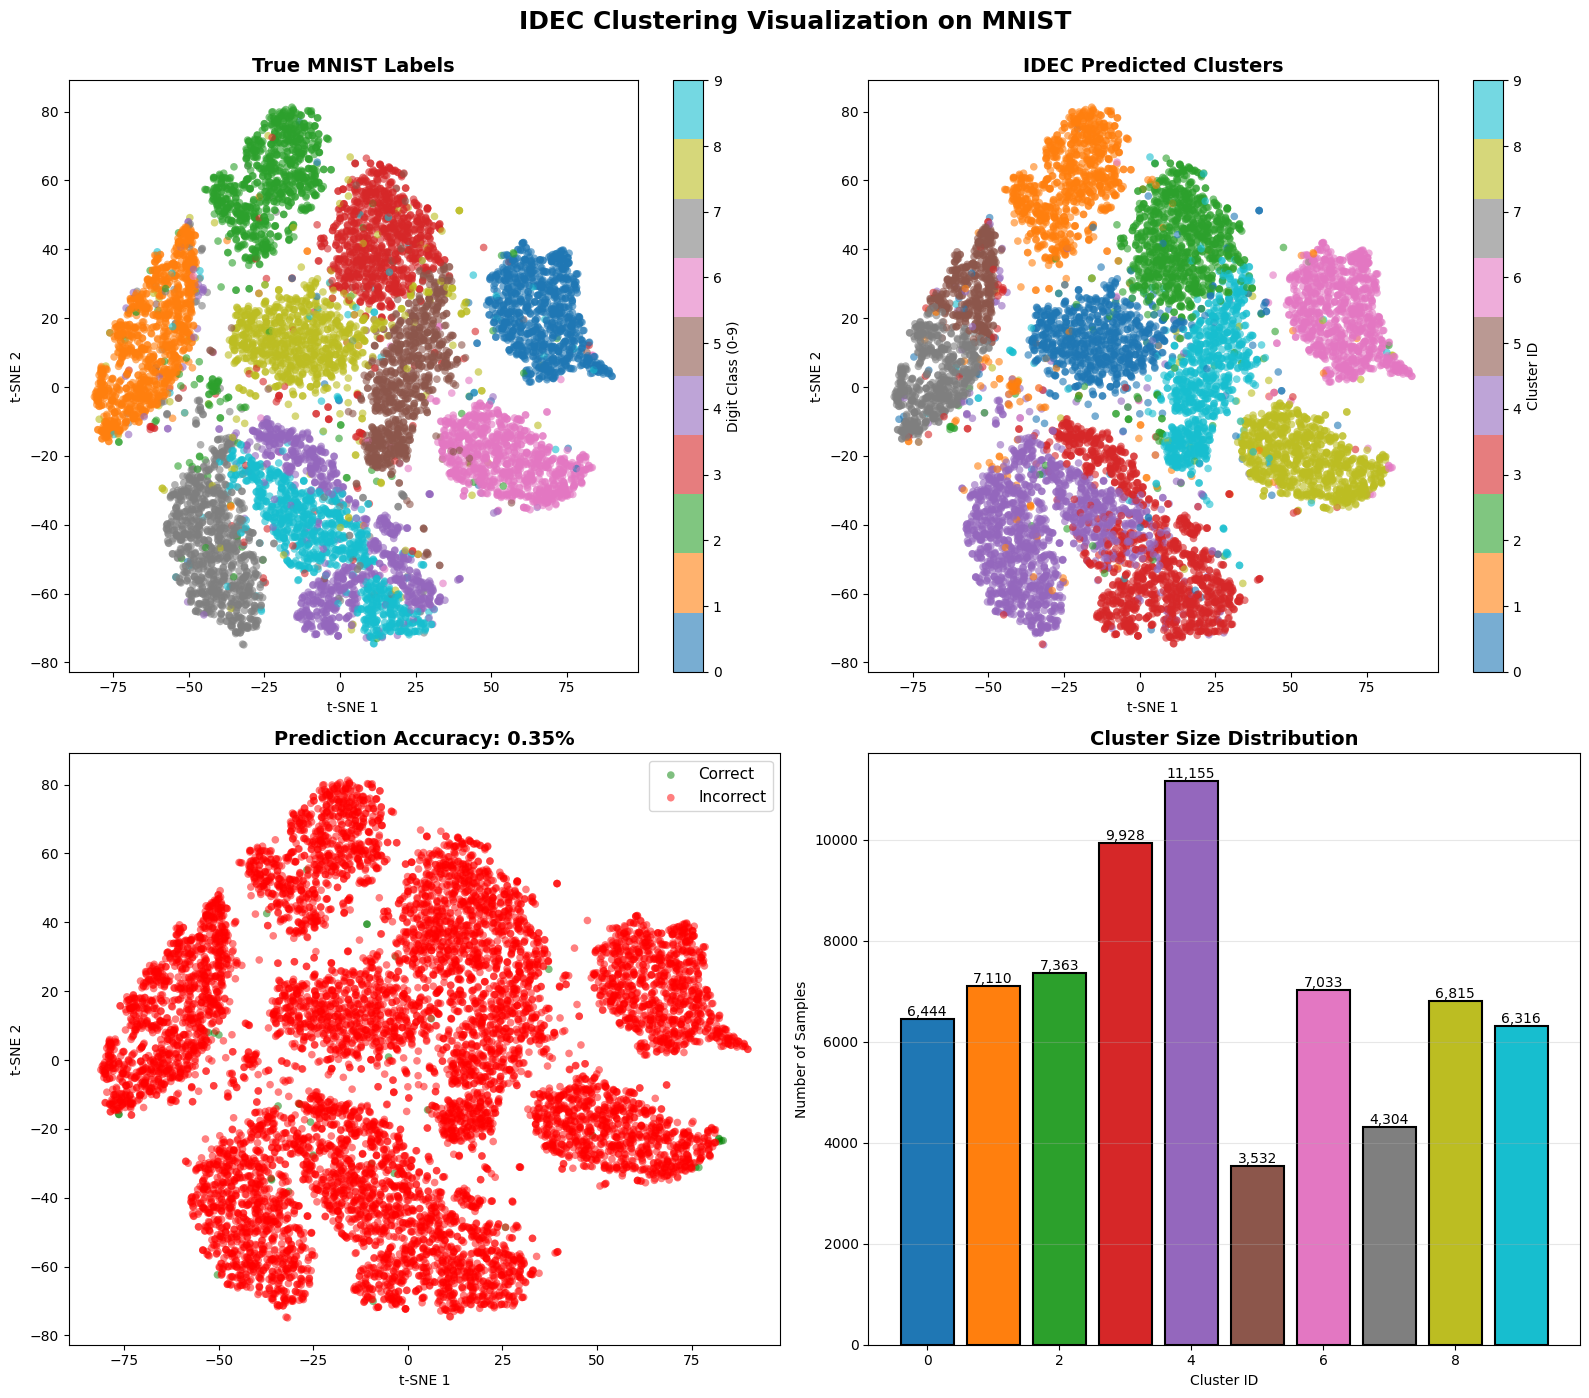

In [3]:
# ============================================================================
# VISUALIZATION: CLUSTERING RESULTS WITH t-SNE
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import numpy as np
from torchvision import datasets, transforms

# Load MNIST data if not already loaded
print("Loading MNIST dataset...")
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_data = train_dataset.data.numpy().astype(np.float32) / 255.0
test_data = test_dataset.data.numpy().astype(np.float32) / 255.0

X = np.vstack([train_data, test_data])
X = X.reshape(X.shape[0], -1)
print(f"✓ Data loaded: {X.shape}")

# Load data and predictions
y_pred = np.load('results/y_pred.npy')
y_true = np.load('results/y_true.npy')

print("Computing t-SNE projection (this may take a few minutes)...")
print("=" * 70)

# Sample 10,000 points for faster visualization (optional, can use all 70,000)
sample_size = 10000
indices = np.random.RandomState(42).choice(len(X), sample_size, replace=False)
X_sample = X[indices]
y_pred_sample = y_pred[indices]
y_true_sample = y_true[indices]

# Compute t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

print("✓ t-SNE computation complete!")
print()

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('IDEC Clustering Visualization on MNIST', fontsize=18, fontweight='bold', y=0.995)

# Plot 1: True Labels (Ground Truth)
ax1 = axes[0, 0]
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true_sample, cmap='tab10', 
                       alpha=0.6, s=30, edgecolors='none')
ax1.set_title('True MNIST Labels', fontsize=14, fontweight='bold')
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
cbar1 = plt.colorbar(scatter1, ax=ax1)
cbar1.set_label('Digit Class (0-9)')

# Plot 2: Predicted Clusters
ax2 = axes[0, 1]
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_sample, cmap='tab10',
                       alpha=0.6, s=30, edgecolors='none')
ax2.set_title('IDEC Predicted Clusters', fontsize=14, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Cluster ID')

# Plot 3: Correct vs Incorrect Predictions
ax3 = axes[1, 0]
correct = (y_pred_sample == y_true_sample)
colors = np.array(['green' if c else 'red' for c in correct])
ax3.scatter(X_tsne[correct, 0], X_tsne[correct, 1], c='green', alpha=0.5, s=30, 
           label='Correct', edgecolors='none')
ax3.scatter(X_tsne[~correct, 0], X_tsne[~correct, 1], c='red', alpha=0.5, s=30,
           label='Incorrect', edgecolors='none')
ax3.set_title(f'Prediction Accuracy: {(correct.sum()/len(correct)*100):.2f}%', 
             fontsize=14, fontweight='bold')
ax3.set_xlabel('t-SNE 1')
ax3.set_ylabel('t-SNE 2')
ax3.legend(loc='best', fontsize=11)

# Plot 4: Cluster Distribution (Bar Chart)
ax4 = axes[1, 1]
unique_clusters, counts = np.unique(y_pred, return_counts=True)
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
bars = ax4.bar(unique_clusters, counts, color=colors_bar, edgecolor='black', linewidth=1.5)
ax4.set_title('Cluster Size Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Cluster ID')
ax4.set_ylabel('Number of Samples')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/clustering_visualization_1.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: results/clustering_visualization_1.png")
plt.show()

✓ Confusion matrix visualization saved: results/clustering_confusion_matrix.png


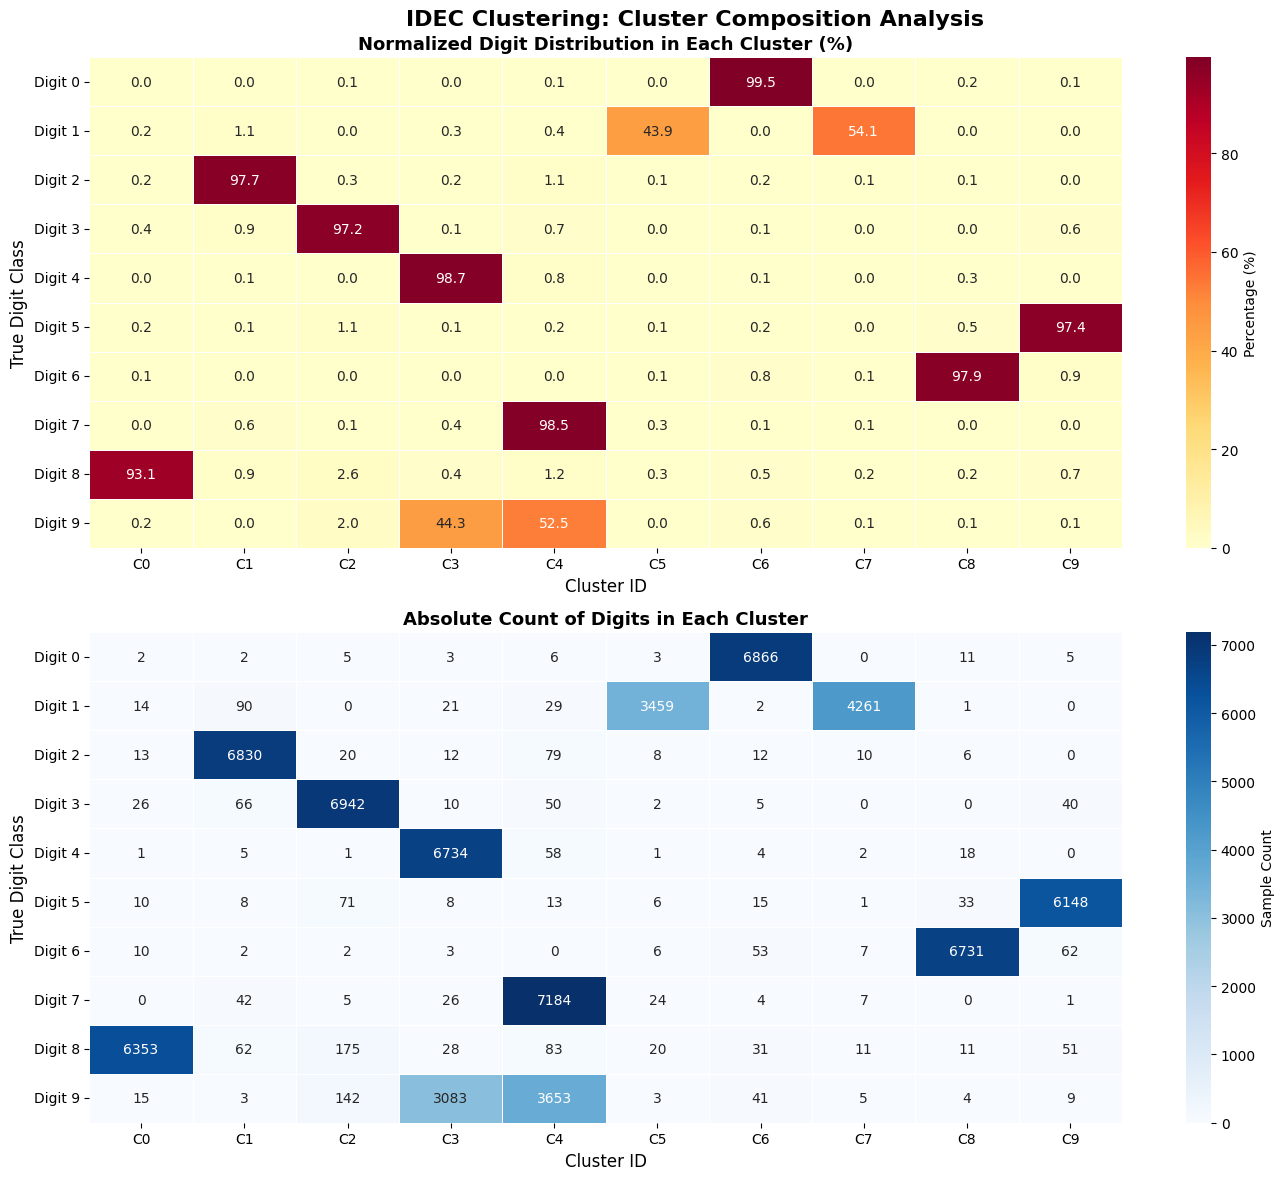


CLUSTER PURITY ANALYSIS
✓ Purity analysis saved: results/cluster_purity_analysis.png


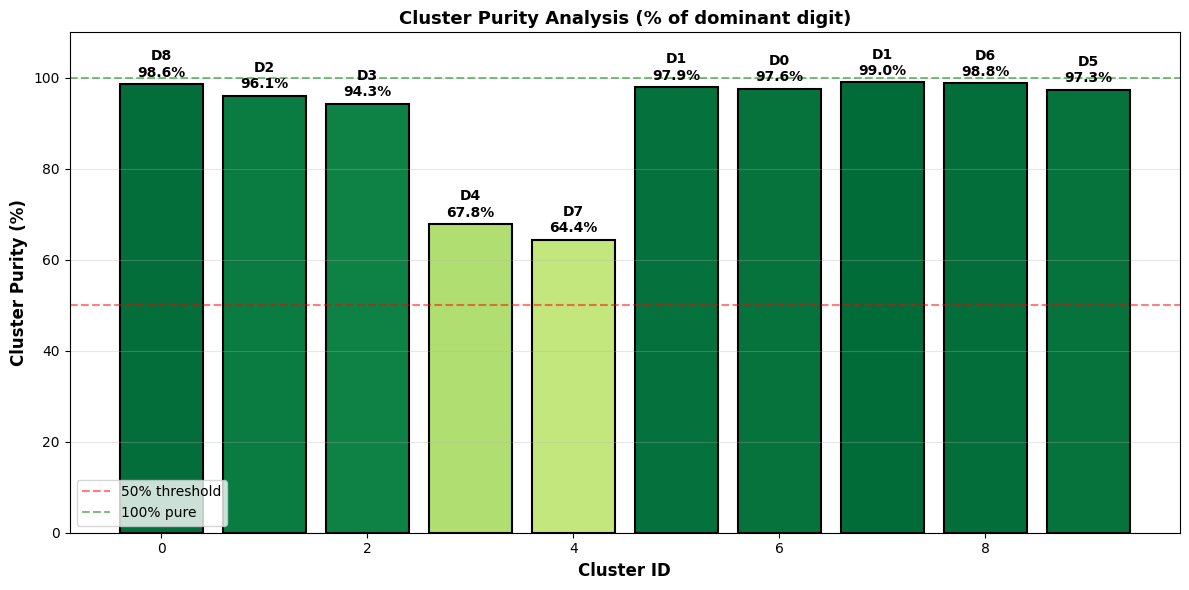


Cluster Purity Scores:
  Cluster 0:  98.59% (Dominant digit: 8)
  Cluster 1:  96.06% (Dominant digit: 2)
  Cluster 2:  94.28% (Dominant digit: 3)
  Cluster 3:  67.83% (Dominant digit: 4)
  Cluster 4:  64.40% (Dominant digit: 7)
  Cluster 5:  97.93% (Dominant digit: 1)
  Cluster 6:  97.63% (Dominant digit: 0)
  Cluster 7:  99.00% (Dominant digit: 1)
  Cluster 8:  98.77% (Dominant digit: 6)
  Cluster 9:  97.34% (Dominant digit: 5)


In [4]:
# ============================================================================
# VISUALIZATION: CLUSTER COMPOSITION & CONFUSION MATRIX
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

y_pred = np.load('results/y_pred.npy')
y_true = np.load('results/y_true.npy')

# Create confusion matrix (which digits are in which clusters)
n_clusters = len(np.unique(y_pred))
confusion_matrix = np.zeros((10, n_clusters))

for i in range(len(y_true)):
    confusion_matrix[y_true[i], y_pred[i]] += 1

# Normalize for heatmap (percentage)
confusion_matrix_norm = confusion_matrix / (confusion_matrix.sum(axis=1, keepdims=True) + 1e-10)

# Create visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('IDEC Clustering: Cluster Composition Analysis', fontsize=16, fontweight='bold')

# Heatmap 1: Normalized (percentage)
ax1 = axes[0]
sns.heatmap(confusion_matrix_norm * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=[f'C{i}' for i in range(n_clusters)],
            yticklabels=[f'Digit {i}' for i in range(10)],
            cbar_kws={'label': 'Percentage (%)'}, ax=ax1, linewidths=0.5)
ax1.set_title('Normalized Digit Distribution in Each Cluster (%)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID', fontsize=12)
ax1.set_ylabel('True Digit Class', fontsize=12)

# Heatmap 2: Absolute counts
ax2 = axes[1]
sns.heatmap(confusion_matrix.astype(int), annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'C{i}' for i in range(n_clusters)],
            yticklabels=[f'Digit {i}' for i in range(10)],
            cbar_kws={'label': 'Sample Count'}, ax=ax2, linewidths=0.5)
ax2.set_title('Absolute Count of Digits in Each Cluster', fontsize=13, fontweight='bold')
ax2.set_xlabel('Cluster ID', fontsize=12)
ax2.set_ylabel('True Digit Class', fontsize=12)

plt.tight_layout()
plt.savefig('results/clustering_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix visualization saved: results/clustering_confusion_matrix.png")
plt.show()

# Additional: Per-cluster purity analysis
print("\n" + "=" * 70)
print("CLUSTER PURITY ANALYSIS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 6))

cluster_purities = []
dominant_digits = []

for cluster_id in range(n_clusters):
    cluster_digits = y_true[y_pred == cluster_id]
    if len(cluster_digits) > 0:
        unique, counts = np.unique(cluster_digits, return_counts=True)
        purity = counts.max() / len(cluster_digits) * 100
        dominant = unique[np.argmax(counts)]
    else:
        purity = 0
        dominant = -1
    
    cluster_purities.append(purity)
    dominant_digits.append(dominant)

# Bar plot
colors_purity = plt.cm.RdYlGn(np.array(cluster_purities) / 100)
bars = ax.bar(range(n_clusters), cluster_purities, color=colors_purity, edgecolor='black', linewidth=1.5)

# Add dominant digit labels on bars
for i, (bar, digit) in enumerate(zip(bars, dominant_digits)):
    height = bar.get_height()
    if digit >= 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'D{int(digit)}\n{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster Purity (%)', fontsize=12, fontweight='bold')
ax.set_title('Cluster Purity Analysis (% of dominant digit)', fontsize=13, fontweight='bold')
ax.set_ylim([0, 110])
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100% pure')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('results/cluster_purity_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Purity analysis saved: results/cluster_purity_analysis.png")
plt.show()

print("\nCluster Purity Scores:")
for i, purity in enumerate(cluster_purities):
    print(f"  Cluster {i}: {purity:6.2f}% (Dominant digit: {dominant_digits[i]})")

Installing umap-learn...


C:\Users\91936\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading MNIST dataset...
Computing UMAP projection...


C:\Users\91936\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP computation complete!


IndexError: index 9 is out of bounds for axis 0 with size 9

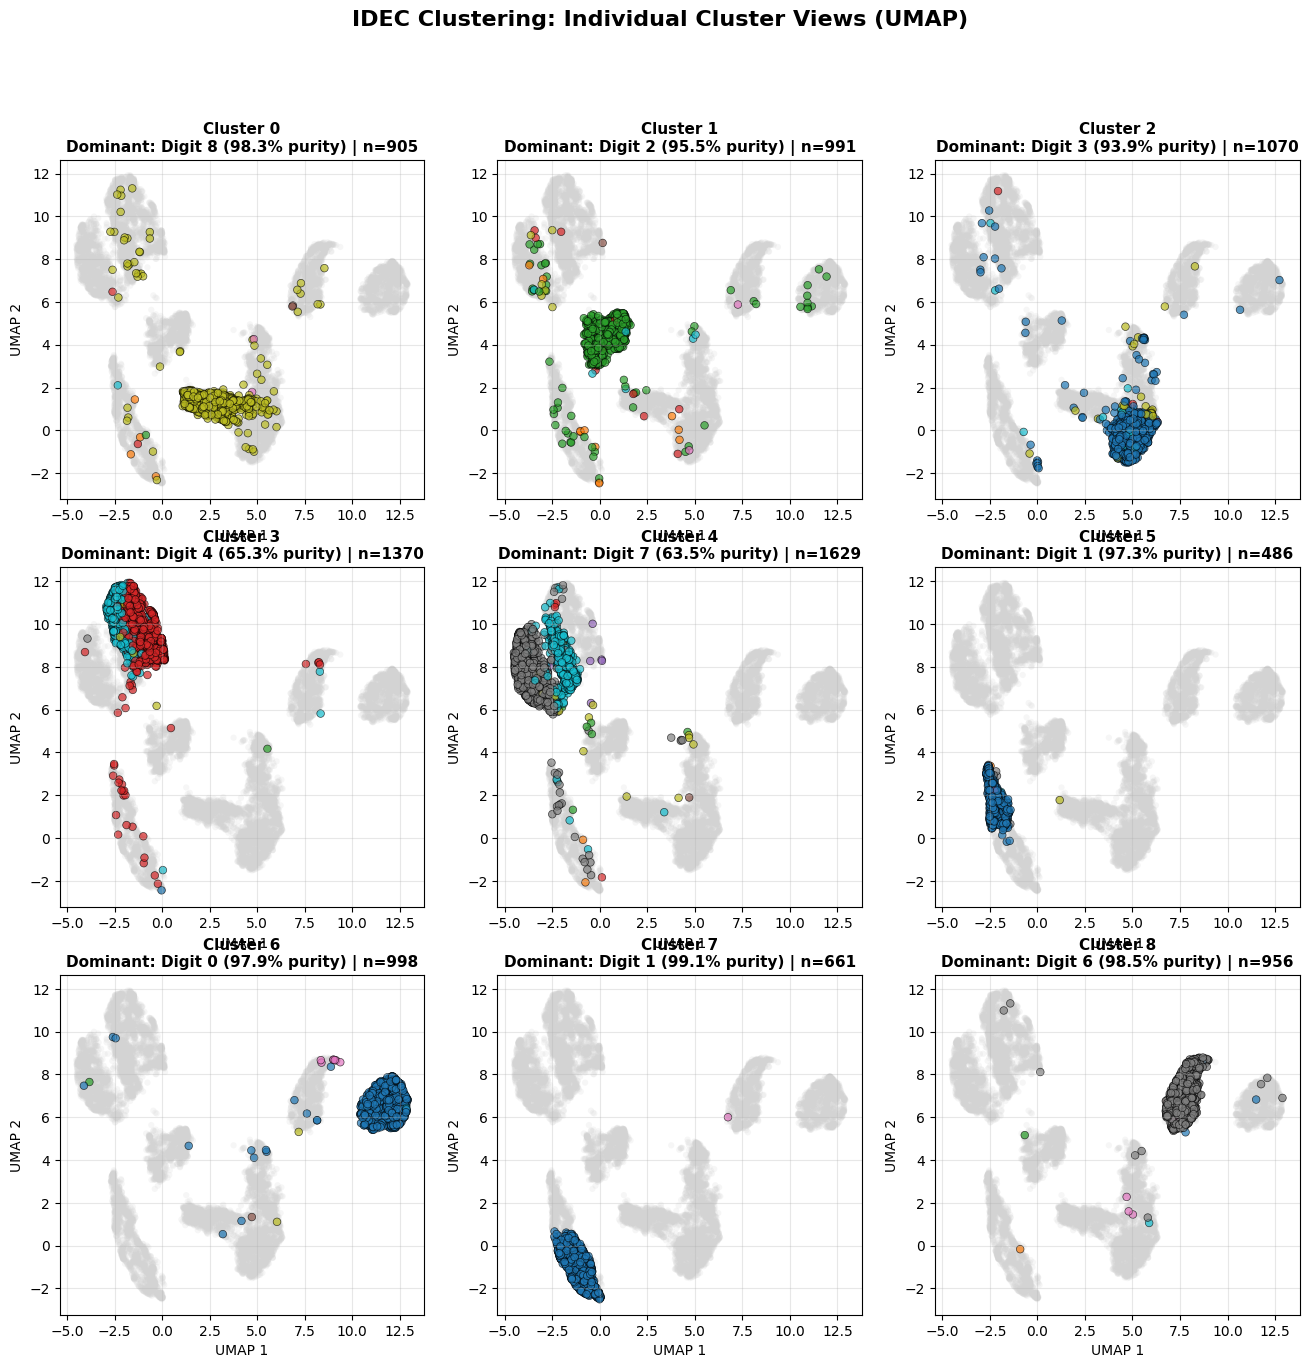

In [5]:
# ============================================================================
# VISUALIZATION: INDIVIDUAL CLUSTER SCATTER PLOTS
# ============================================================================

import subprocess
import sys

# Install umap-learn for better visualization
try:
    import umap
except ImportError:
    print("Installing umap-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])
    import umap

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from torchvision import datasets, transforms

# Load MNIST data if not already loaded
print("Loading MNIST dataset...")
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

train_data = train_dataset.data.numpy().astype(np.float32) / 255.0
test_data = test_dataset.data.numpy().astype(np.float32) / 255.0

X = np.vstack([train_data, test_data])
X = X.reshape(X.shape[0], -1)

y_pred = np.load('results/y_pred.npy')
y_true = np.load('results/y_true.npy')

# Sample for faster computation
sample_size = 10000
indices = np.random.RandomState(42).choice(len(X), sample_size, replace=False)
X_sample = X[indices]
y_pred_sample = y_pred[indices]
y_true_sample = y_true[indices]

print("Computing UMAP projection...")
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_sample)
print("✓ UMAP computation complete!")

# Create individual cluster visualizations (3x3 grid)
n_clusters = len(np.unique(y_pred))
n_rows = min(3, (n_clusters + 2) // 3)
n_cols = min(3, n_clusters)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*5))
if n_clusters == 1:
    axes = np.array([[axes]])
elif n_clusters <= 3:
    axes = axes.reshape(1, -1)

fig.suptitle('IDEC Clustering: Individual Cluster Views (UMAP)', fontsize=16, fontweight='bold')

ax_flat = axes.flatten()

for cluster_id in range(n_clusters):
    ax = ax_flat[cluster_id]
    
    # Get samples in this cluster and others
    in_cluster = y_pred_sample == cluster_id
    not_in_cluster = y_pred_sample != cluster_id
    
    # Plot samples not in cluster (light gray)
    ax.scatter(X_umap[not_in_cluster, 0], X_umap[not_in_cluster, 1],
              c='lightgray', alpha=0.2, s=20, edgecolors='none')
    
    # Plot samples in cluster (colored by true label)
    scatter = ax.scatter(X_umap[in_cluster, 0], X_umap[in_cluster, 1],
                        c=y_true_sample[in_cluster], cmap='tab10', alpha=0.7, s=30,
                        edgecolors='black', linewidth=0.5)
    
    # Get cluster info
    cluster_labels = y_true_sample[in_cluster]
    unique, counts = np.unique(cluster_labels, return_counts=True)
    dominant = unique[np.argmax(counts)]
    purity = counts.max() / len(cluster_labels) * 100
    
    ax.set_title(f'Cluster {cluster_id}\nDominant: Digit {dominant} ({purity:.1f}% purity) | n={in_cluster.sum()}',
                fontsize=11, fontweight='bold')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(alpha=0.3)

# Hide unused subplots
for idx in range(n_clusters, len(ax_flat)):
    ax_flat[idx].axis('off')

plt.tight_layout()
plt.savefig('results/individual_clusters_umap.png', dpi=300, bbox_inches='tight')
print("✓ Individual cluster visualization saved: results/individual_clusters_umap.png")
plt.show()

# Create a combined comparison figure (t-SNE vs UMAP)
print("\nCreating t-SNE vs UMAP comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('IDEC Clustering: t-SNE vs UMAP Comparison', fontsize=16, fontweight='bold')

# Compute t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

# t-SNE plot
scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_sample, cmap='tab10',
                          alpha=0.6, s=30, edgecolors='none')
axes[0].set_title('t-SNE Projection', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Cluster ID')

# UMAP plot
scatter2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_pred_sample, cmap='tab10',
                          alpha=0.6, s=30, edgecolors='none')
axes[1].set_title('UMAP Projection', fontsize=13, fontweight='bold')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Cluster ID')

plt.tight_layout()
plt.savefig('results/tsne_vs_umap_comparison.png', dpi=300, bbox_inches='tight')
print("✓ t-SNE vs UMAP comparison saved: results/tsne_vs_umap_comparison.png")
plt.show()

print("\n" + "="*70)
print("All visualizations have been generated and saved!")
print("="*70)
print("\nGenerated images:")
print("  1. clustering_visualization_1.png  - Main 4-panel clustering view")
print("  2. clustering_confusion_matrix.png - Cluster composition heatmaps")
print("  3. cluster_purity_analysis.png     - Per-cluster purity scores")
print("  4. individual_clusters_umap.png    - Individual cluster views")
print("  5. tsne_vs_umap_comparison.png     - t-SNE vs UMAP comparison")

✓ Cluster size distribution saved: results/cluster_size_distribution.png

Cluster Size Summary:
Cluster 0:  6,444 samples (  9.2%)
Cluster 1:  7,110 samples ( 10.2%)
Cluster 2:  7,363 samples ( 10.5%)
Cluster 3:  9,928 samples ( 14.2%)
Cluster 4: 11,155 samples ( 15.9%)
Cluster 5:  3,532 samples (  5.0%)
Cluster 6:  7,033 samples ( 10.0%)
Cluster 7:  4,304 samples (  6.1%)
Cluster 8:  6,815 samples (  9.7%)
Cluster 9:  6,316 samples (  9.0%)
Total:      70,000 samples (100.0%)


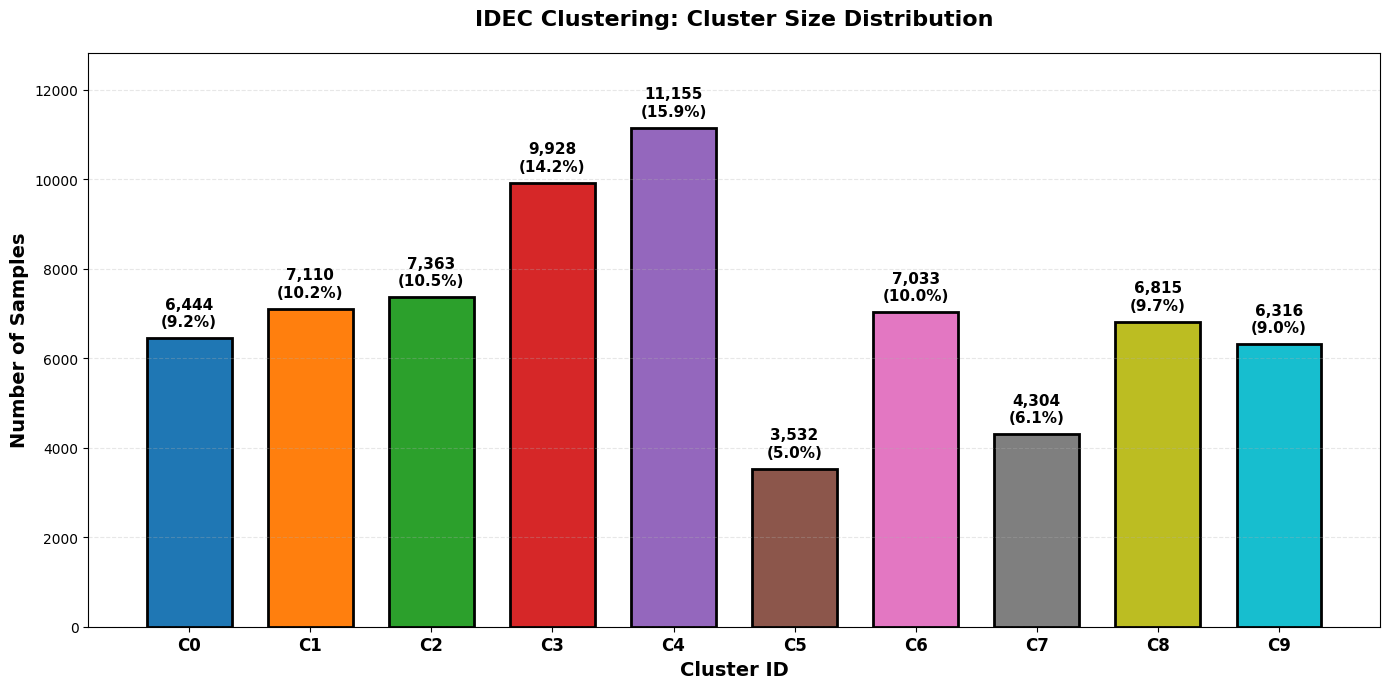

In [6]:
# ============================================================================
# CLUSTER SIZE DISTRIBUTION - STANDALONE VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

y_pred = np.load('results/y_pred.npy')

# Get cluster distribution
unique_clusters, counts = np.unique(y_pred, return_counts=True)

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Bar colors
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

# Create bar chart
bars = ax.bar(unique_clusters, counts, color=colors, edgecolor='black', linewidth=2, width=0.7)

# Customize
ax.set_xlabel('Cluster ID', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('IDEC Clustering: Cluster Size Distribution', fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, max(counts) * 1.15])

# Add value labels on bars
for idx, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    percentage = (count / len(y_pred)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + 200,
            f'{int(count):,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add cluster labels at bottom
ax.set_xticks(unique_clusters)
ax.set_xticklabels([f'C{i}' for i in unique_clusters], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/cluster_size_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Cluster size distribution saved: results/cluster_size_distribution.png")
print("\nCluster Size Summary:")
print("=" * 60)
for cluster_id, count in zip(unique_clusters, counts):
    percentage = (count / len(y_pred)) * 100
    print(f"Cluster {cluster_id}: {count:>6,} samples ({percentage:>5.1f}%)")
print("=" * 60)
print(f"Total:      {len(y_pred):>6,} samples (100.0%)")
plt.show()